# Plot chromosome QC plots

1) Chromosome lengths vs ref length
2) Highlight possible errors and Genomic repeats (Telo, Centro)

In [3]:
library(tidyverse)
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Extended QC

In [4]:
# Assmbly fasta
fai = "../../data/ref/T2T-CHM13.v2.fasta.fai"
# load beds
nucflag_status = "../../analysis_other/nucflag/TUE_02_03UL.nucflag_misasm.bed"
gap_stats = "../../assembly/qc/phased_verkko/TUE_02_03UL_old/gap_stats.both.n_regions.bed"
rm = "../../analysis_other/repeatmasker/TUE_02_03UL/rm_summary_filtered_satellites.bed"
colors = "../../assembly/qc/phased_verkko/TUE_02_03UL_old/colors.tsv"
rm_telo = "../../analysis_other/repeatmasker/TUE_02_03UL/rm_filtered_telo.bed"
telo = "../../assembly/qc/phased_verkko/TUE_02_03UL_old/T2T_contigs.unphased_telomeric_repeat_windows.csv"
seqinfo = "../../assembly/qc/phased_verkko/TUE_02_03UL_old/T2T_contigs.unphased.seqinfo.txt"

Create custom genome from Assembly

In [5]:
# Load ref chromosome lengths from Fasta Index

dt_fai <- read_tsv(fai, 
    col_names = c("chromosome", "length", "offset", "linebases", "linewidth", "qualoffset"),
    col_types = "cnnnnn") %>%
    filter(chromosome != "chrM")

#NAME	Name of this reference sequence
#LENGTH	Total length of this reference sequence, in bases
#OFFSET	Offset in the FASTA/FASTQ file of this sequence's first base
#LINEBASES	The number of bases on each line
#LINEWIDTH	The number of bytes in each line, including the newline
#QUALOFFSET Offset of sequence's first quality within the FASTQ file


# Order reference chromosomes by length (descending) for faceting
chromosome_order <- c(
    paste0("chr", 1:22), "chrX", "chrY"
)

dt_fai <- dt_fai %>%
    mutate(chromosome = factor(chromosome, levels = chromosome_order)) %>%
    filter(!is.na(chromosome)) # Remove chromosomes not in our hardcoded list

head(dt_fai)

chromosome,length,offset,linebases,linewidth
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
chr1,248387328,6,50,51
chr2,242696752,253355087,50,51
chr3,201105948,500905781,50,51
chr4,193574945,706033854,50,51
chr5,182045439,903480304,50,51
chr6,172126628,1089166658,50,51


In [6]:
# Load colors

dt_colors <- read_tsv(colors, col_types = "ccc")
head(dt_colors)
nrow(dt_colors)

contig,color,chromosome
<chr>,<chr>,<chr>
haplotype1-0000001,#D55E00,chr6
haplotype1-0000002,#CCA0BF,chr18
haplotype1-0000003,#E69F00,chr1
haplotype1-0000004,#338CC2,chr19
haplotype1-0000005,#5699E9,chr9
haplotype1-0000006,#567DE9,chr16


[1] 754

In [7]:
# Load assembly lengths (seqinfo)

dt_l <- read_tsv(seqinfo, col_names = c("contig", "length", "n_N"), col_types = "cnn")
head(dt_l)
nrow(dt_l)

contig,length,n_N
<chr>,<dbl>,<dbl>
haplotype1-0000001,172883413,0
haplotype1-0000002,79365531,0
haplotype1-0000003,244330139,45986
haplotype1-0000004,62434507,22500
haplotype1-0000005,136367670,0
haplotype1-0000006,92814540,0


[1] 754

In [8]:
# Merge assembly lengths and colours

dt <- inner_join(dt_l, dt_colors, by = "contig") %>% 
    separate(col = contig, into =  c("hap", NA), sep = "-", remove = F) %>%
    mutate(hap = str_replace_all(hap, "lotype", "")) %>%
    mutate(chromosome = factor(chromosome, levels = chromosome_order)) %>%
    group_by(chromosome, hap) %>%
    # Order contigs by length (descending) to determine stacking order
    # Longest contigs will be at the "start" (bottom/left after coord_flip)
    arrange(desc(length), .by_group = TRUE) %>%
    mutate(
        # Calculate cumulative start position of each contig within its haplotype bar
        contig_start_on_hap_bar = cumsum(lag(length, default = 0))
    ) %>%
    ungroup() %>%
    # Global arrangement to ensure ggplot stacks in the desired order (for contigs within bars)
    # And to match facet order for chromosomes
    arrange(chromosome, hap, desc(length)) # 'chromosome' is already factored

hap_plot_order <- rev(sort(unique(dt$hap)))

head(dt)
nrow(dt)
hap_plot_order

contig,hap,length,n_N,color,chromosome,contig_start_on_hap_bar
<chr>,<chr>,<dbl>,<dbl>,<chr>,<fct>,<dbl>
haplotype1-0000003,hap1,244330139,45986,#E69F00,chr1,0
haplotype1-0000043,hap1,195540,0,#E69F00,chr1,244330139
haplotype1-0000050,hap1,164272,0,#E69F00,chr1,244525679
haplotype1-0000049,hap1,151283,0,#E69F00,chr1,244689951
haplotype1-0000060,hap1,129126,0,#E69F00,chr1,244841234
haplotype1-0000058,hap1,107105,0,#E69F00,chr1,244970360


[1] 754

[1] "unassigned" "hap2"       "hap1"

In [9]:
join_bed <- function(bed, dt, hap_levels_for_plot = hap_plot_order, feature_height = 0.8, feature_y_offset = -0.1) {
    contig_info_for_join <- dt %>%
    select(contig, chromosome, hap, contig_start_on_hap_bar) %>%
    distinct(contig, .keep_all = TRUE)

    features_to_plot <- bed %>%
    inner_join(contig_info_for_join, by = "contig") %>%
    mutate(
        # Absolute positions on the (now horizontal) length axis
        abs_feature_start = contig_start_on_hap_bar + start,
        abs_feature_end = contig_start_on_hap_bar + end,
        # Define y positions for the rectangles (on the now vertical hap axis)
        y_center = abs_feature_start + (abs_feature_end - abs_feature_start)/2,
        y_spread = abs_feature_end - abs_feature_start
    )

    return(features_to_plot)

}    

In [10]:
# load bedfile with gaps

dt_gaps <- read_tsv(gap_stats, col_names = c("contig", "start", "end", "label", "length"), col_types = "cddcd")
dt_gaps_plot <- join_bed(dt_gaps, dt)
head(dt_gaps_plot)

contig,start,end,label,length,chromosome,hap,contig_start_on_hap_bar,abs_feature_start,abs_feature_end,y_center,y_spread
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
haplotype1-0000003,138530683,138538183,N_region,7500,chr1,hap1,0,138530683,138538183,138534433,7500
haplotype1-0000003,156566351,156604837,N_region,38486,chr1,hap1,0,156566351,156604837,156585594,38486
haplotype1-0000004,22843527,22851027,N_region,7500,chr19,hap1,0,22843527,22851027,22847277,7500
haplotype1-0000004,26429069,26436569,N_region,7500,chr19,hap1,0,26429069,26436569,26432819,7500
haplotype1-0000004,45800564,45808064,N_region,7500,chr19,hap1,0,45800564,45808064,45804314,7500
haplotype1-0000007,72626188,72633688,N_region,7500,chr3,hap1,0,72626188,72633688,72629938,7500


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


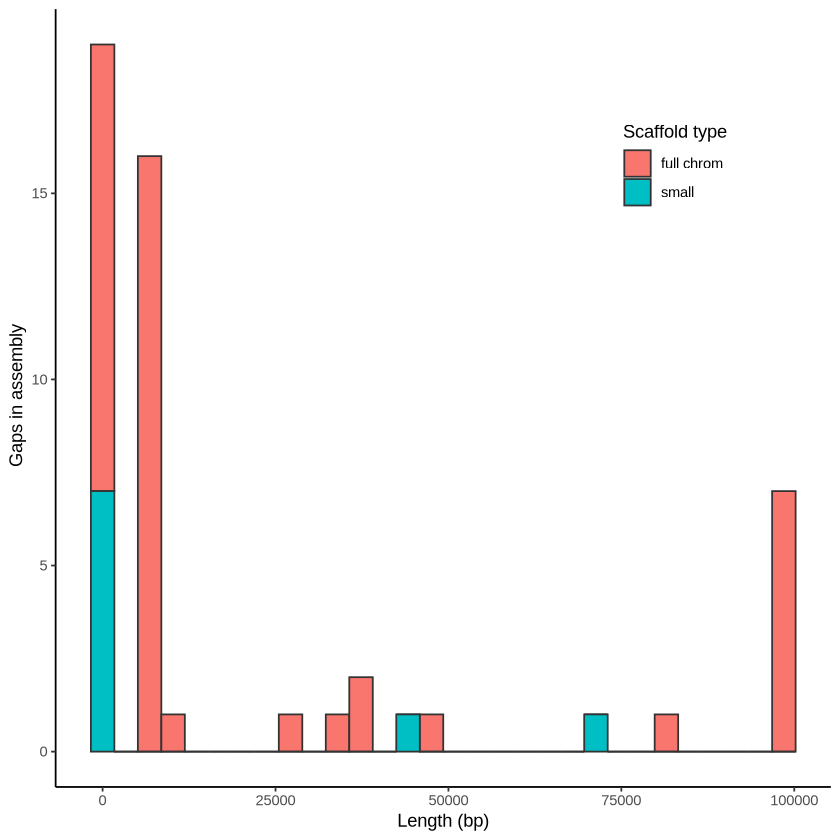

In [11]:

dt_gaps_length <- dt_gaps %>%
    inner_join(dt,by = "contig") %>%
    mutate(contig_type = ifelse(length.y > 10e6, "full chrom", "small"))

p0 <- ggplot(dt_gaps_length, aes(x=length.x, fill = contig_type)) +
    geom_histogram(colour = "grey20") +
    theme_classic() +
    theme(legend.position = "inside", legend.position.inside = c(0.8,0.8)) +
    labs(x = "Length (bp)", y = " Gaps in assembly", fill = "Scaffold type")

p0
ggsave(plot = p0, filename = "../../doc/img/for_presentations/gap_lengths.GE-MED-T2T00.png", height = 3, width = 4)


In [56]:

# load bedfile with nucflag 
dt_nucflag <- read_tsv(nucflag_status, col_names = c("contig", "start", "end", "label", "length"), col_types = "cddcd")
dt_nucflag_plot <- join_bed(dt_nucflag, dt)
head(dt_nucflag_plot)

contig,start,end,label,chromosome,hap,contig_start_on_hap_bar,abs_feature_start,abs_feature_end,y_center,y_spread
<chr>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
haplotype1-0000001,13679050,13783023,MISJOIN,chr6,hap1,0,13679050,13783023,13731036,103973
haplotype1-0000001,57594464,57607788,HET,chr6,hap1,0,57594464,57607788,57601126,13324
haplotype1-0000001,58520301,58561568,HET,chr6,hap1,0,58520301,58561568,58540934,41267
haplotype1-0000001,58919223,58925372,HET,chr6,hap1,0,58919223,58925372,58922298,6149
haplotype1-0000001,58935713,58955615,HET,chr6,hap1,0,58935713,58955615,58945664,19902
haplotype1-0000001,58978635,59021346,HET,chr6,hap1,0,58978635,59021346,58999990,42711



      COLLAPSE COLLAPSE_OTHER   COLLAPSE_VAR            HET        MISJOIN 
            15            282             27            835           1170 

Warning message in geom_histogram(stat = "count", colour = "grey20"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


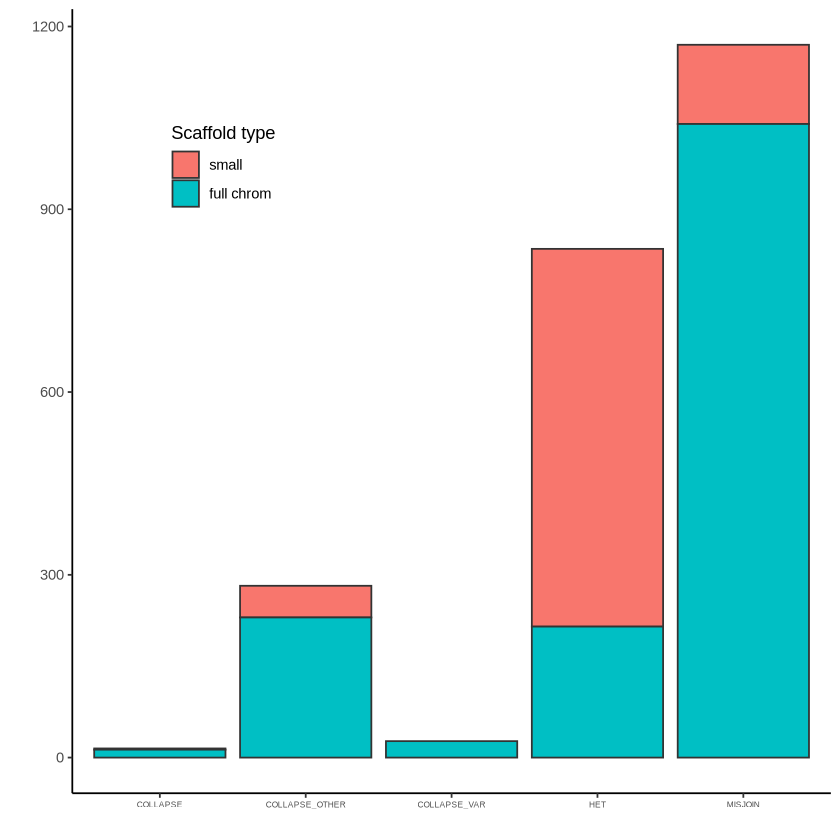

In [59]:
dt_nucflag_l <- dt_nucflag %>%
    inner_join(dt,by = "contig") %>%
    mutate(contig_type = ifelse(length > 10e6, "small", "full chrom")) %>%
    mutate(contig_type = factor(contig_type, levels = c("small", "full chrom")))

table(dt_nucflag$label)

p01 <- ggplot(dt_nucflag_l, aes(x=label, fill = contig_type)) +
    geom_histogram(stat = "count", colour = "grey20") +
    theme_classic() +
    theme(legend.position = "inside",
     legend.position.inside = c(0.2,0.8),
     axis.text.x=element_text(size=5)) +
    labs(x = "", y = "", fill = "Scaffold type")

p01
ggsave(plot = p01, filename = "../../doc/img/for_presentations/nucflag_types.GE-MED-T2T00.png", height = 3, width = 4)

In [13]:
# load bedfile with satellites 
dt_satellites <- read_tsv(rm, col_names = c("contig", "start", "end", "family", "name"), col_types = "cddcc")
dt_satellites_plot <- join_bed(dt_satellites, dt)
head(dt_satellites_plot)

contig,start,end,family,name,chromosome,hap,contig_start_on_hap_bar,abs_feature_start,abs_feature_end,y_center,y_spread
<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
haplotype1-0000001,5742,6841,subtelo,TAR1,chr6,hap1,0,5742,6841,6291.5,1099
haplotype1-0000001,104916,105098,subtelo,TAR1,chr6,hap1,0,104916,105098,105007.0,182
haplotype1-0000001,105121,106298,subtelo,TAR1,chr6,hap1,0,105121,106298,105709.5,1177
haplotype1-0000001,928572,928692,Unknown,BSR/Beta,chr6,hap1,0,928572,928692,928632.0,120
haplotype1-0000001,2602677,2602916,centr,SST1,chr6,hap1,0,2602677,2602916,2602796.5,239
haplotype1-0000001,2602997,2603151,Unknown,SST1v,chr6,hap1,0,2602997,2603151,2603074.0,154


In [14]:
# load bedfile with telomeres from Repatmasker
dt_rmtelo <- read_tsv(rm_telo, col_names = c("contig", "start", "end", "family", "name"), col_types = "cddcc")
dt_rmtelo_plot <- join_bed(dt_rmtelo, dt)
head(dt_rmtelo_plot)

contig,start,end,family,name,X6,X7,chromosome,hap,contig_start_on_hap_bar,abs_feature_start,abs_feature_end,y_center,y_spread
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
haplotype1-0000001,177,5741,Simple_repeat:Unknown,(CCCTAA)n,+,2550255,chr6,hap1,0,177,5741,2959.0,5564
haplotype1-0000001,6891685,6891724,Simple_repeat:Unknown,(CCCTAA)n,+,2550255,chr6,hap1,0,6891685,6891724,6891704.5,39
haplotype1-0000002,1,4879,Simple_repeat:Unknown,(CCCTAA)n,+,2550255,chr18,hap1,0,1,4879,2440.0,4878
haplotype1-0000002,93235,93276,Simple_repeat:Unknown,(CCCTAA)n,+,2550255,chr18,hap1,0,93235,93276,93255.5,41
haplotype1-0000003,2,6804,Simple_repeat:Unknown,(CCCTAA)n,+,2550255,chr1,hap1,0,2,6804,3403.0,6802
haplotype1-0000003,78664129,78664164,Simple_repeat:Unknown,(CCCTAA)n,+,2550255,chr1,hap1,0,78664129,78664164,78664146.5,35


In [15]:
# load bedfile with telomeres from Repatmasker
dt_telo <- read_csv(telo, col_types = "cddd") %>%
    separate(id, sep="_", into=c("contig", "location")) %>%
    group_by(contig) %>%
    mutate(repeat_number = max(forward_repeat_number, reverse_repeat_number)) %>%
    ungroup() %>%
    filter(repeat_number>10) %>%
    select(contig, location, repeat_number) %>%
    inner_join(dt_l, by = "contig") %>%
    mutate(start = ifelse(location == "Start", 0, length - repeat_number*5)) %>%
    mutate(end = ifelse(location == "Start", repeat_number*5, length)) %>%
    select(contig, start, end)

dt_telo_plot <- join_bed(dt_telo, dt)

head(dt_telo_plot)

contig,start,end,chromosome,hap,contig_start_on_hap_bar,abs_feature_start,abs_feature_end,y_center,y_spread
<chr>,<dbl>,<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
haplotype1-0000001,0,820,chr6,hap1,0,0,820,410.0,820
haplotype1-0000002,0,825,chr18,hap1,0,0,825,412.5,825
haplotype1-0000003,0,815,chr1,hap1,0,0,815,407.5,815
haplotype1-0000004,0,825,chr19,hap1,0,0,825,412.5,825
haplotype1-0000005,0,820,chr9,hap1,0,0,820,410.0,820
haplotype1-0000006,0,825,chr16,hap1,0,0,825,412.5,825


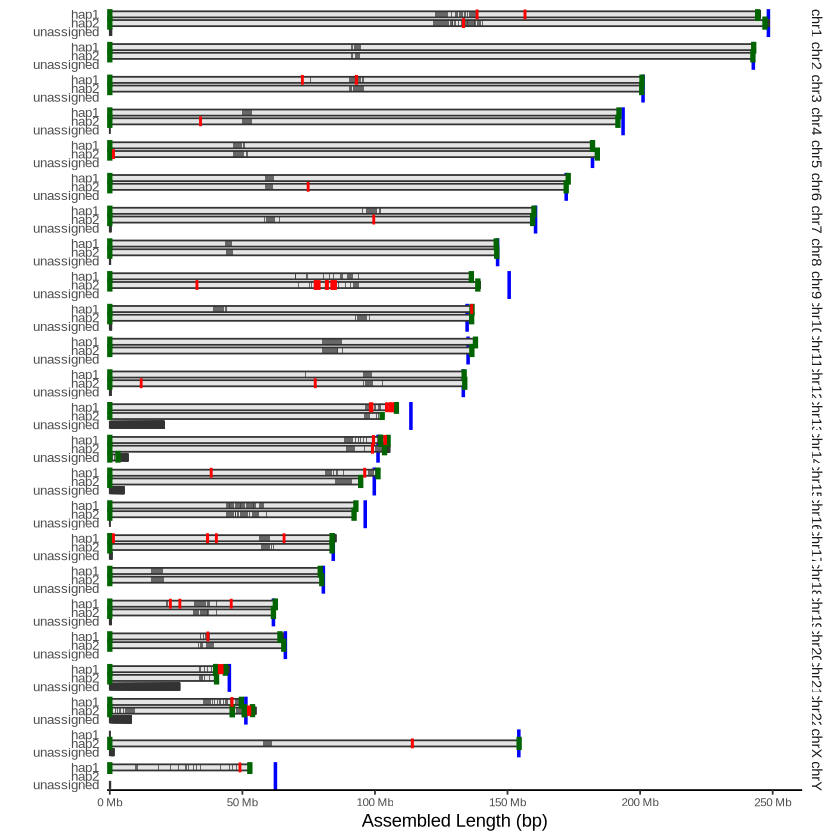

In [54]:
p1 <- ggplot(dt, aes(x=hap, y = length)) +
    geom_hline(data = dt_fai,
        aes(yintercept = length), 
        lwd = 1, lty = 1, colour = "blue") +
    geom_bar(stat = "identity", col = "grey20", fill = "grey90", width = 0.7) + 
    geom_tile(data = dt_satellites_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "grey20", linewidth = 1, alpha = 0.7, width = 0.7,
            ) +
    geom_tile(data = dt_telo_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "darkgreen", colour = "darkgreen", linewidth = 1.5, alpha = 0.7, width = 0.9,
            ) +
    #geom_tile(data = dt_nucflag_plot,
    #              aes(y = y_center, height=y_spread),
    #              fill = "darkorange",colour = "darkorange", linewidth = 1, alpha = 0.7, width = 0.7,
    #        ) +
    geom_tile(data = dt_gaps_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "red", colour = "red", linewidth = 0.8, alpha = 0.9, width = 0.8,
            ) +
    coord_flip() +
    facet_grid(rows = vars(chromosome)) +
    theme_classic() +
    guides(fill="none") +
    # Format y-axis (length) labels to Mb and expand to start at 0
    scale_y_continuous(labels = scales::unit_format(unit = "Mb", scale = 1e-6), 
                       expand = expansion(mult = c(0, 0.05))) +
    # Control order of haplotypes on the y-axis (after coord_flip)
    scale_x_discrete(limits = hap_plot_order) +
    expand_limits(y=-1e6) + # Create some space before bar starts 
    labs(y = "Assembled Length (bp)", x = "") + # Clearer x-axis label (haplotype)
    theme(
        strip.text.y.left = element_text(angle = 0, hjust = 1, size=8), # Horizontal chromosome labels
        strip.background = element_blank(),
        panel.spacing.y = unit(0.2, "lines"), # Reduce space between facets
        legend.position = "none",
        axis.text.x = element_text(size=7), # Adjust size of length labels
        axis.text.y = element_text(size=8),  # Adjust size of hap labels
        axis.line.y = element_blank(),
        axis.ticks.y = element_blank(),

    )

p1
ggsave(plot = p1, filename = "../../doc/img/chromosome_plot_GE-MED-T2T00.gaps.with_unassigned.png", height = 15, width = 8)


Warning message:
“Removed 1062 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 1062 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_tile()`).”


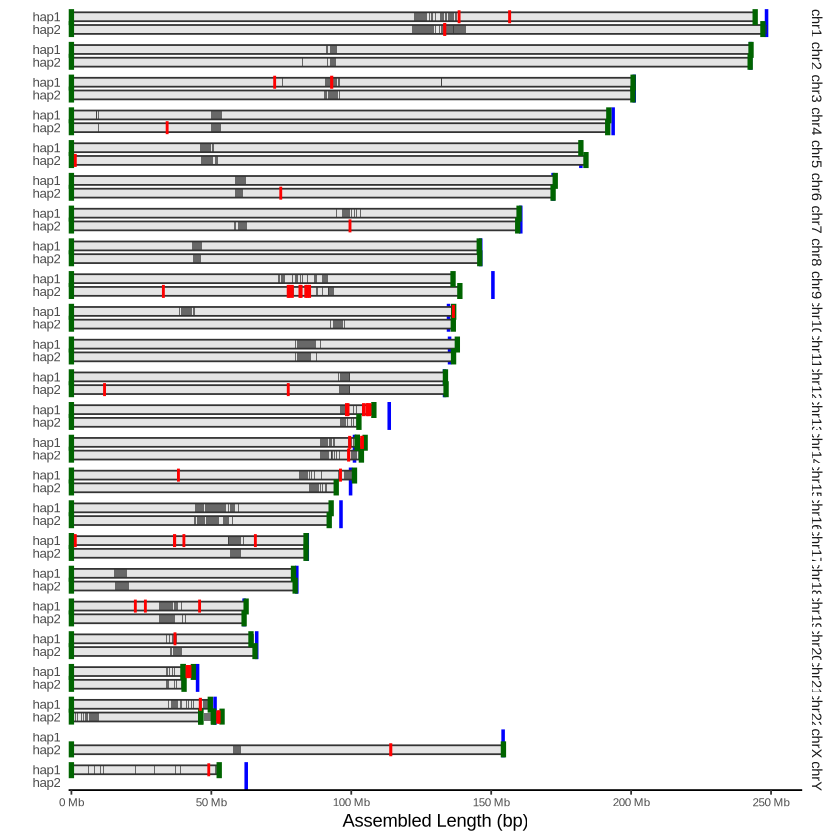

In [24]:
# With Gaps, Clean, No Unassigned only chr scale contigs

p2 <- ggplot(dt %>%
             filter(length >= 10e6) %>%
             filter(hap != "unassigned"),
         aes(x=hap, y = length)) +
    geom_hline(data = dt_fai,
        aes(yintercept = length), 
        lwd = 1, lty = 1, colour = "blue") +
    geom_bar(stat = "identity", col = "grey20", fill = "grey90", width = 0.7) + 
    geom_tile(data = dt_satellites_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "grey20", linewidth = 1, alpha = 0.7, width = 0.7,
            ) +
    geom_tile(data = dt_telo_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "darkgreen", colour = "darkgreen", linewidth = 1.5, alpha = 0.7, width = 0.9,
            ) +
    #geom_tile(data = dt_nucflag_plot,
    #              aes(y = y_center, height=y_spread),
    #              fill = "darkorange",colour = "darkorange", linewidth = 1, alpha = 0.7, width = 0.7,
    #        ) +
    geom_tile(data = dt_gaps_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "red", colour = "red", linewidth = 0.8, alpha = 0.9, width = 0.8,
            ) +
    coord_flip() +
    facet_grid(rows = vars(chromosome)) +
    theme_classic() +
    guides(fill="none") +
    # Format y-axis (length) labels to Mb and expand to start at 0
    scale_y_continuous(labels = scales::unit_format(unit = "Mb", scale = 1e-6), 
                       expand = expansion(mult = c(0, 0.05))) +
    # Control order of haplotypes on the y-axis (after coord_flip)
    scale_x_discrete(limits = c("hap2", "hap1")) +
    expand_limits(y=-1e6) + # Create some space before bar starts 
    labs(y = "Assembled Length (bp)", x = "") + # Clearer x-axis label (haplotype)
    theme(
        strip.text.y.left = element_text(angle = 0, hjust = 1, size=8), # Horizontal chromosome labels
        strip.background = element_blank(),
        panel.spacing.y = unit(0.2, "lines"), # Reduce space between facets
        legend.position = "none",
        axis.text.x = element_text(size=7), # Adjust size of length labels
        axis.text.y = element_text(size=8),  # Adjust size of hap labels
        axis.line.y = element_blank(),
        axis.ticks.y = element_blank(),

    )

p2
ggsave(plot = p2, filename = "../../doc/img/chromosome_plot_GE-MED-T2T00.gaps.clean.png", height = 15, width = 8)


Warning message:
“Removed 1062 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 1118 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 1062 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 1118 rows containing missing values or values outside the scale range
(`geom_tile()`).”


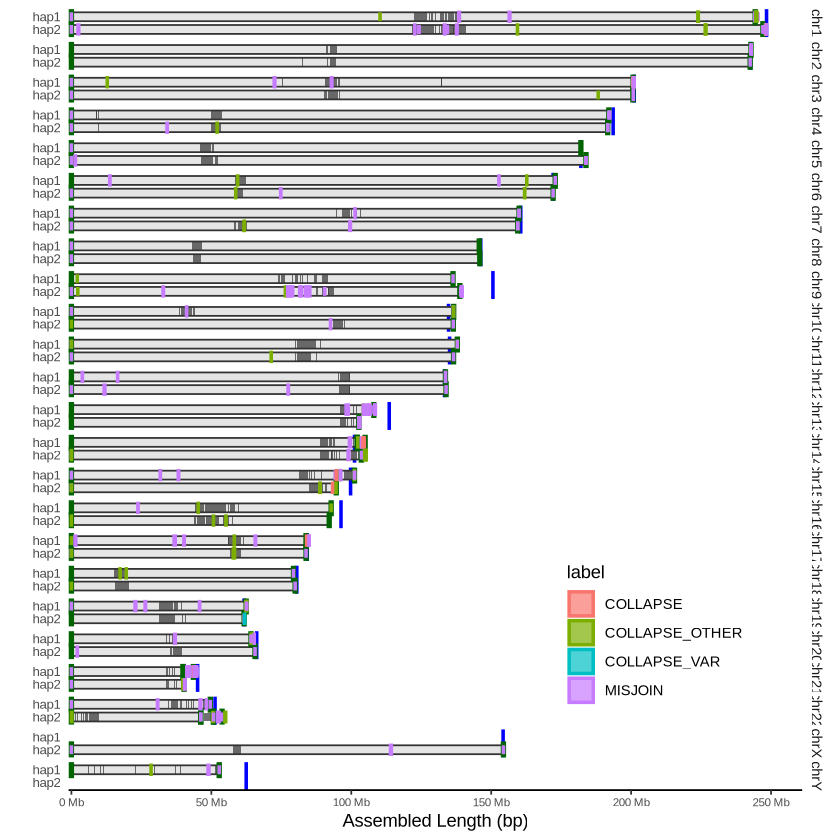

In [58]:
# With Misasm, Clean, No Unassigned only chr scale contigs

p3 <- ggplot(dt %>%
             filter(length >= 10e6) %>%
             filter(hap != "unassigned"),
         aes(x=hap, y = length)) +
    geom_hline(data = dt_fai,
        aes(yintercept = length), 
        lwd = 1, lty = 1, colour = "blue") +
    geom_bar(stat = "identity", col = "grey20", fill = "grey90", width = 0.7) + 
    geom_tile(data = dt_satellites_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "grey20", linewidth = 1, alpha = 0.7, width = 0.7,
            ) +
    geom_tile(data = dt_telo_plot,
                  aes(y = y_center, height=y_spread),
                  fill = "darkgreen", colour = "darkgreen", linewidth = 1.5, alpha = 0.7, width = 0.9,
            ) +
    geom_tile(data = dt_nucflag_plot %>% filter(label != "HET"),
                  aes(y = y_center, height=y_spread, fill = label, colour = label),
                  linewidth = 1, alpha = 0.7, width = 0.7,
            ) +
    #scale_fill_discrete(name = "Assembly")
    #geom_tile(data = dt_gaps_plot,
    #              aes(y = y_center, height=y_spread),
    #              fill = "red", colour = "red", linewidth = 0.8, alpha = 0.9, width = 0.8,
    #        ) +
    coord_flip() +
    facet_grid(rows = vars(chromosome)) +
    theme_classic() +
    #guides(fill="none") +
    # Format y-axis (length) labels to Mb and expand to start at 0
    scale_y_continuous(labels = scales::unit_format(unit = "Mb", scale = 1e-6), 
                       expand = expansion(mult = c(0, 0.05))) +
    # Control order of haplotypes on the y-axis (after coord_flip)
    scale_x_discrete(limits = c("hap2", "hap1")) +
    expand_limits(y=-1e6) + # Create some space before bar starts 
    labs(y = "Assembled Length (bp)", x = "") + # Clearer x-axis label (haplotype)
    theme(
        strip.text.y.left = element_text(angle = 0, hjust = 1, size=8), # Horizontal chromosome labels
        strip.background = element_blank(),
        panel.spacing.y = unit(0.2, "lines"), # Reduce space between facets
        legend.position = "inside",
        legend.position.inside = c(0.8,0.2),
        axis.text.x = element_text(size=7), # Adjust size of length labels
        axis.text.y = element_text(size=8),  # Adjust size of hap labels
        axis.line.y = element_blank(),
        axis.ticks.y = element_blank(),

    )

p3
ggsave(plot = p3, filename = "../../doc/img/chromosome_plot_GE-MED-T2T00.nucflag.clean.png", height = 15, width = 8)
